## Day 12 

I will start by looking over some areas in Lecture 09 that I feel like I missed or didn't analyse deeply enough:

Let's say we are repeatedly measuring the position or flux or something else of a star, and call the measurements, $x_1, x_2,...,x_N$

We know there is some true $\mu$ for this star, but our measurements can fluctuate because of the sky, noise, etc and we model this with $\sigma$.

So our model then is:

$$x_i \sim N(\mu, \sigma^2)$$

We have two unknowns here, and the likelihood is gaussian as we assumed gaussian noise:

$$L = p(\{x_i\}|\mu,\sigma) = \prod_{i=1}^N \frac{1}{\sigma\sqrt{2\pi}} \exp\left(\frac{-(x_i-\mu)^2}{2\sigma^2}\right),$$

> We can go over the equation just for recap,  $(x_i - \mu)^2$ is how far the particular measurement is away from the true $\mu$, and then we divide by $\sigma^2$ to see how far away that is in units of the std. 
> So if we have $\mu = 10$ and $\sigma=0.01$, then seeing $10.2$ is very surprising and the likelihood would disagree for the pair of $\mu$ and $\sigma$
>
> We are also assuming independance so we multiply

We need a 2D prior in this case, $p(\mu, \sigma)$

$$p(\mu,\sigma) \propto \frac{1}{\sigma},\; {\rm for} \; \mu_{\rm min} < \mu < \mu_{\rm max} \; {\rm and} \; \sigma_{\rm min} < \sigma < \sigma_{\rm max}.$$

This means that the mean for the mean we are taking a uniform prior, $p(\mu) = \text{constant}$ and for sigma we are taking $p(\sigma) \propto 1/\sigma$. For sigma, we are taking uniform ignorance but on a logarithmic scale.

So then we go back to Bayes' theorem, and exclude the evidence (denominator) as we just care about the shape of the posterior so:

$$
p(\mu,\sigma|\{x_i\})
\propto
p(\{x_i\}|\mu,\sigma)
p(\mu,\sigma)
$$

$$
p(\mu,\sigma|\{x_i\})
\propto
\frac{1}{\sigma^{N+1}}
\exp\left[
-\frac{1}{2\sigma^2}
\sum_{i=1}^{N}(x_i-\mu)^2
\right]
$$

Where we just took our likelihood and multiplied it by the prior.

This then forms:

$$
p(\{x_i\}|\mu,\sigma)p(\mu,\sigma)
=
C
\frac{1}{\sigma^{N+1}}
\prod_{i=1}^{N}
\exp\left[
-\frac{(x_i-\mu)^2}{2\sigma^2}
\right]
$$

Now we take the logarithm of this posterior, to form:

$$
\ln[p(\mu,\sigma|\{x_i\})]
=
\text{constant}
-
(N+1)\ln\sigma
-
\frac{1}{2\sigma^2}
\sum_i(x_i-\mu)^2

$$

With some manipulation that the lectures didn't really go into we can get:

$$
\ln[p(\mu,\sigma|\{x_i\})]
=
\text{constant}
-
(N+1)\ln\sigma
-
\frac{N}{2\sigma^2}
\left[
(\bar{x}-\mu)^2+V
\right]
$$

as

$$
\sum_i(x_i-\mu)^2
=
N\left[(\bar{x}-\mu)^2+V\right]
$$

Just based on our final equation, we can see that the posterior favours when $\mu \approx \bar{x}$ as then we are taking away less.

For the case of $(N,\overline{x},V)=(10,1,4)$ we have the code:

In [21]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
np.random.seed(42)

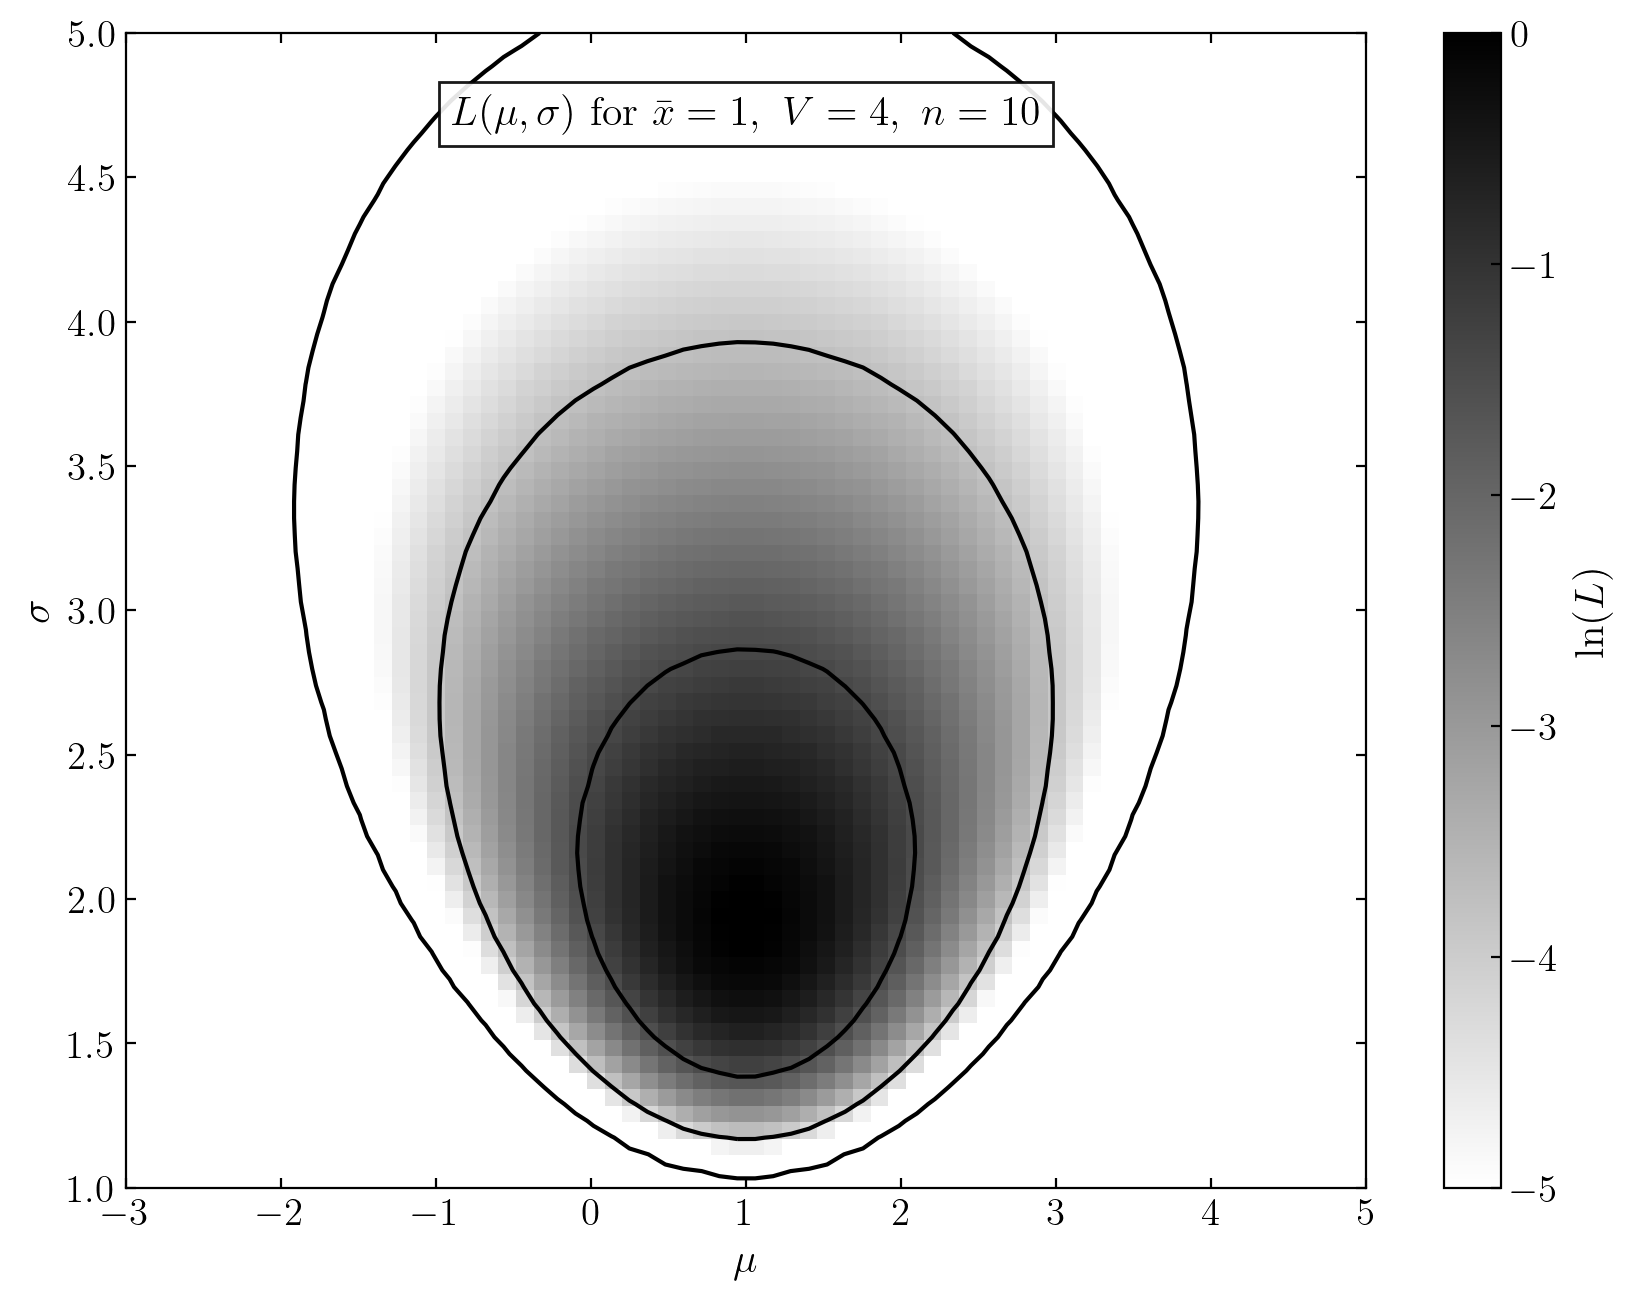

In [32]:
# %load code/fig_likelihood_gaussian.py
"""
Log-likelihood for Gaussian Distribution
----------------------------------------
Figure5.4
An illustration of the logarithm of the posterior probability density
function for :math:`\mu` and :math:`\sigma`, :math:`L_p(\mu,\sigma)`
(see eq. 5.58) for data drawn from a Gaussian distribution and N = 10, x = 1,
and V = 4. The maximum of :math:`L_p` is renormalized to 0, and color coded as
shown in the legend. The maximum value of :math:`L_p` is at :math:`\mu_0 = 1.0`
and :math:`\sigma_0 = 1.8`. The contours enclose the regions that contain
0.683, 0.955, and 0.997 of the cumulative (integrated) posterior probability.
"""
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from astroML.plotting.mcmc import convert_to_stdev

def gauss_logL(xbar, V, n, sigma, mu):
    """Equation 5.57: gaussian likelihood"""
    return (-(n + 1) * np.log(sigma)
            - 0.5 * n * ((xbar - mu) ** 2 + V) / sigma ** 2)

#------------------------------------------------------------
# Define the grid and compute logL
sigma = np.linspace(1, 5, 70)
mu = np.linspace(-3, 5, 70)
xbar = 1
V = 4
n = 10

logL = gauss_logL(xbar, V, n, sigma[:, np.newaxis], mu)
logL -= logL.max()

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(10, 7.5))
plt.imshow(logL, origin='lower',
           extent=(mu[0], mu[-1], sigma[0], sigma[-1]),
           cmap=plt.cm.binary,
           aspect='auto')
plt.colorbar().set_label(r'$\ln(L)$', fontsize=15)
plt.clim(-5, 0)

plt.contour(mu, sigma, convert_to_stdev(logL),
            levels=(0.683, 0.955, 0.997),
            colors='k')

plt.text(0.5, 0.93, r'$L(\mu,\sigma)\ \mathrm{for}\ \bar{x}=1,\ V=4,\ n=10$',
         bbox=dict(ec='k', fc='w', alpha=0.9),
         ha='center', va='center', 
         fontsize=15, transform=plt.gca().transAxes)

plt.xlabel(r'$\mu$', fontsize=15)
plt.ylabel(r'$\sigma$', fontsize=15)

plt.show()

And if we do not care about $\sigma$ we can marginalise over it:

$$p(\mu\,|\,\{x_i\}) = \int_0^\infty p(\mu,\sigma|\{x_i\}) d\sigma$$

We are getting rid of it by integrating over all space with respect to it. This actually means that instead of choosing 1 specific value for $\sigma$, we are instead considering all possible values, weighted according to the posterior distribution and combining them. This forms:

$$
p(\mu|\{x_i\})
\propto
\left(
1+
\frac{(\bar{x}-\mu)^2}{V}
\right)^{-N/2}
$$

This becomes the student t distribution, which is like a gaussian but much heavier tails. This makes sense as $\sigma$ is uncertain, so we are less confident about extreme values.

This doesn't contradict the Central Limit Theorem, this can be shown within the following code:

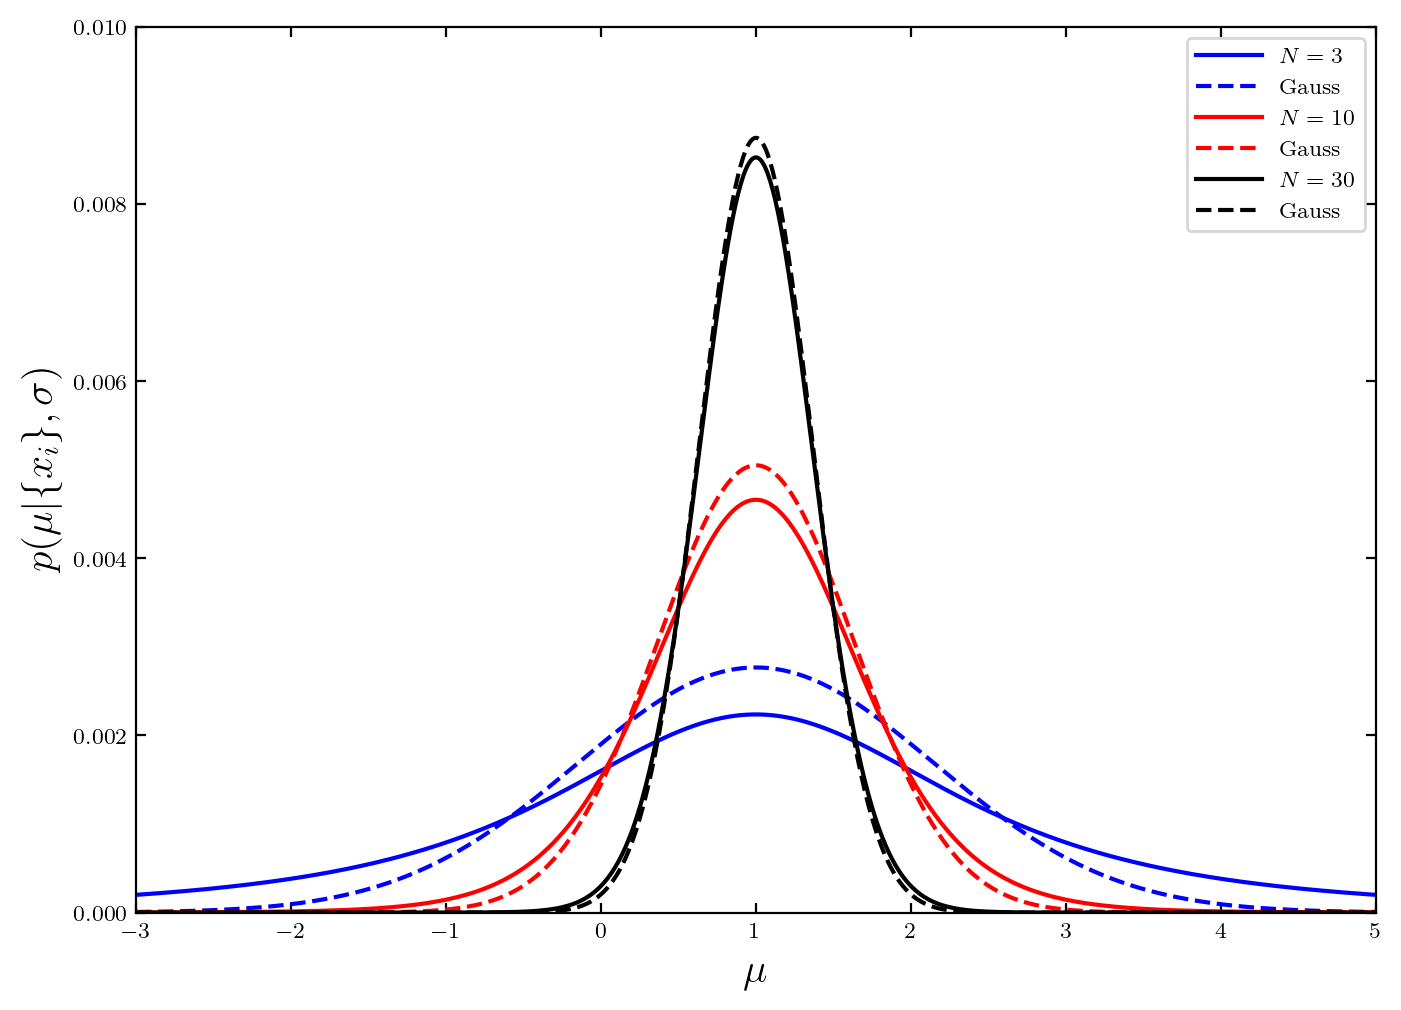

In [23]:
### let's see how Student's t distribution morphs into Gaussian distribution
# let's first choose mean x and variance as in the previous example
mu = np.linspace(-3, 5, 1000)
xbar = 1.0
V = 4.0

# and now let's generate p(mu) for N=3, 10 and 20
def compute_pmu(mu, xbar, V, N):
    p = (1 + (xbar - mu) ** 2 / V) ** (-0.5 * N)
    return p / np.sum(p)
#
N1 = 3
pmu1 = compute_pmu(mu,xbar,V,N1)
G1 = norm(xbar, np.sqrt(V/N1)).pdf(mu) 
G1norm = G1 / np.sum(G1)

N2 = 10
pmu2 = compute_pmu(mu,xbar,V,N2)
G2 = norm(xbar, np.sqrt(V/N2)).pdf(mu) 
G2norm = G2 / np.sum(G2)

N3 = 30
pmu3 = compute_pmu(mu,xbar,V,N3)
G3 = norm(xbar, np.sqrt(V/N3)).pdf(mu) 
G3norm = G3 / np.sum(G3)
 
## plot
fig, ax = plt.subplots(figsize=(8, 5.75))
plt.plot(mu, pmu1, ls='-', c='blue', label=r'$N=3$')
plt.plot(mu, G1norm, ls='--', c='blue', label=r'Gauss')
plt.plot(mu, pmu2, ls='-', c='red', label=r'$N=10$')
plt.plot(mu, G2norm, ls='--', c='red', label=r'Gauss')
plt.plot(mu, pmu3, ls='-', c='black', label=r'$N=30$')
plt.plot(mu, G3norm, ls='--', c='black', label=r'Gauss')

plt.xlim(-3, 5)
plt.ylim(0, 0.01)
plt.xlabel('$\mu$', fontsize=15)
plt.ylabel(r'$p(\mu | \{x_i\},\sigma)$', fontsize=15)
plt.legend()
plt.show() 

## Lecture 9

What we just looked at was a bayesian parameter estimation of a gaussian distribution for $\mu$ and $\sigma$. But what if each value we measure, ${x_i}$ also has a measurement uncertainty?

So, here we are dealing with the spread of the distribution and the measurement uncertainties of data. To put a term to this, we are looking at heteroscedastic Gaussian uncertainties.

When we had homoscedastic uncertainties, the distribution of ${x_i}$ was Gaussian
> This is because we can think of all the measurements being drawn from the exact same normal distribution: $N(0, \sigma^2)$

However with heteroscedastic uncertainties, the distrubution of ${x_i}$ will be non gaussian.
> This is because each measurements are drawn from different gaussians, so our final observation is a mixture of gaussians with different widths, the resulting shape has a sharper peak and much heavier tails than a standard bell curve.

We are trying to find $\mu$ and $\sigma$ parameters of the underlying distribution. 

Our observational noise can follow:

$$
\epsilon_i\sim\mathcal N(0,e_i^2)
$$

But we have two independant gaussian effects with the noise and uncertainties, these variances add, and so our observed measurements follow:

$$
x_i\sim\mathcal N\left(\mu,\sigma^2+e_i^2\right)
$$

Our likelihood is a gaussian pdf with a total variance:

$$
p(x_i|\mu,\sigma,e_i)
=
\frac{1}
{\sqrt{2\pi(\sigma^2+e_i^2)}}
\exp\left[
-\frac{(x_i-\mu)^2}
{2(\sigma^2+e_i^2)}
\right]
$$

Which is once again asking, ig these facts about my population and measurement are true, how plausible is my observed $x_i$ measurement?

So for all the data:

$$
L(\mu,\sigma)
=
\prod_{i=1}^{N}
\frac{1}
{\sqrt{2\pi(\sigma^2+e_i^2)}}
\exp\left[
-\frac{(x_i-\mu)^2}
{2(\sigma^2+e_i^2)}
\right]
$$

If we use uniform priors, we can write the log-posterior pdf as:

$$\ln p = \mathrm{constant} - \frac{1}{2}\sum_{i=1}^N \left( \ln(\sigma^2+e_i^2) + \frac{(x_i-\mu)^2}{(\sigma^2+e_i^2)} \right),$$


We can see that the second term, like always, asks how far is our observed measurement from the proposed mean in units of total variance. The first term shows that the posterior likes an observed scatter that isn't too small but isn't too broad that it has low density everywhere.
 
We can analytically maximise this posterior to find the MAP (maximum a posteriori) value of $\mu$

$$
\mu_0
=
\frac{
\displaystyle\sum_{i=1}^{N}
x_i/(\sigma_0^2+e_i^2)
}{
\displaystyle\sum_{i=1}^{N}
1/(\sigma_0^2+e_i^2)
}
$$

This is basically a weighted mean, and can be written as:

$$
\mu_0
=
\frac{\sum_i w_i x_i}
{\sum_i w_i}
$$

where,

$$
w_i
=
\frac{1}{\sigma_0^2+e_i^2}
$$

This can be found just by differentiating the posterior with respect to the mean and then setting the derivative to 0 and just rearranging.

#### What about the closed form analytical solution for $\sigma_0$?

It doesnt exist. 

Instead we can compute it numerically by plotting $\ln p$ on a grid

This will allow us to know the variance by the shape and width of the probability distribution:

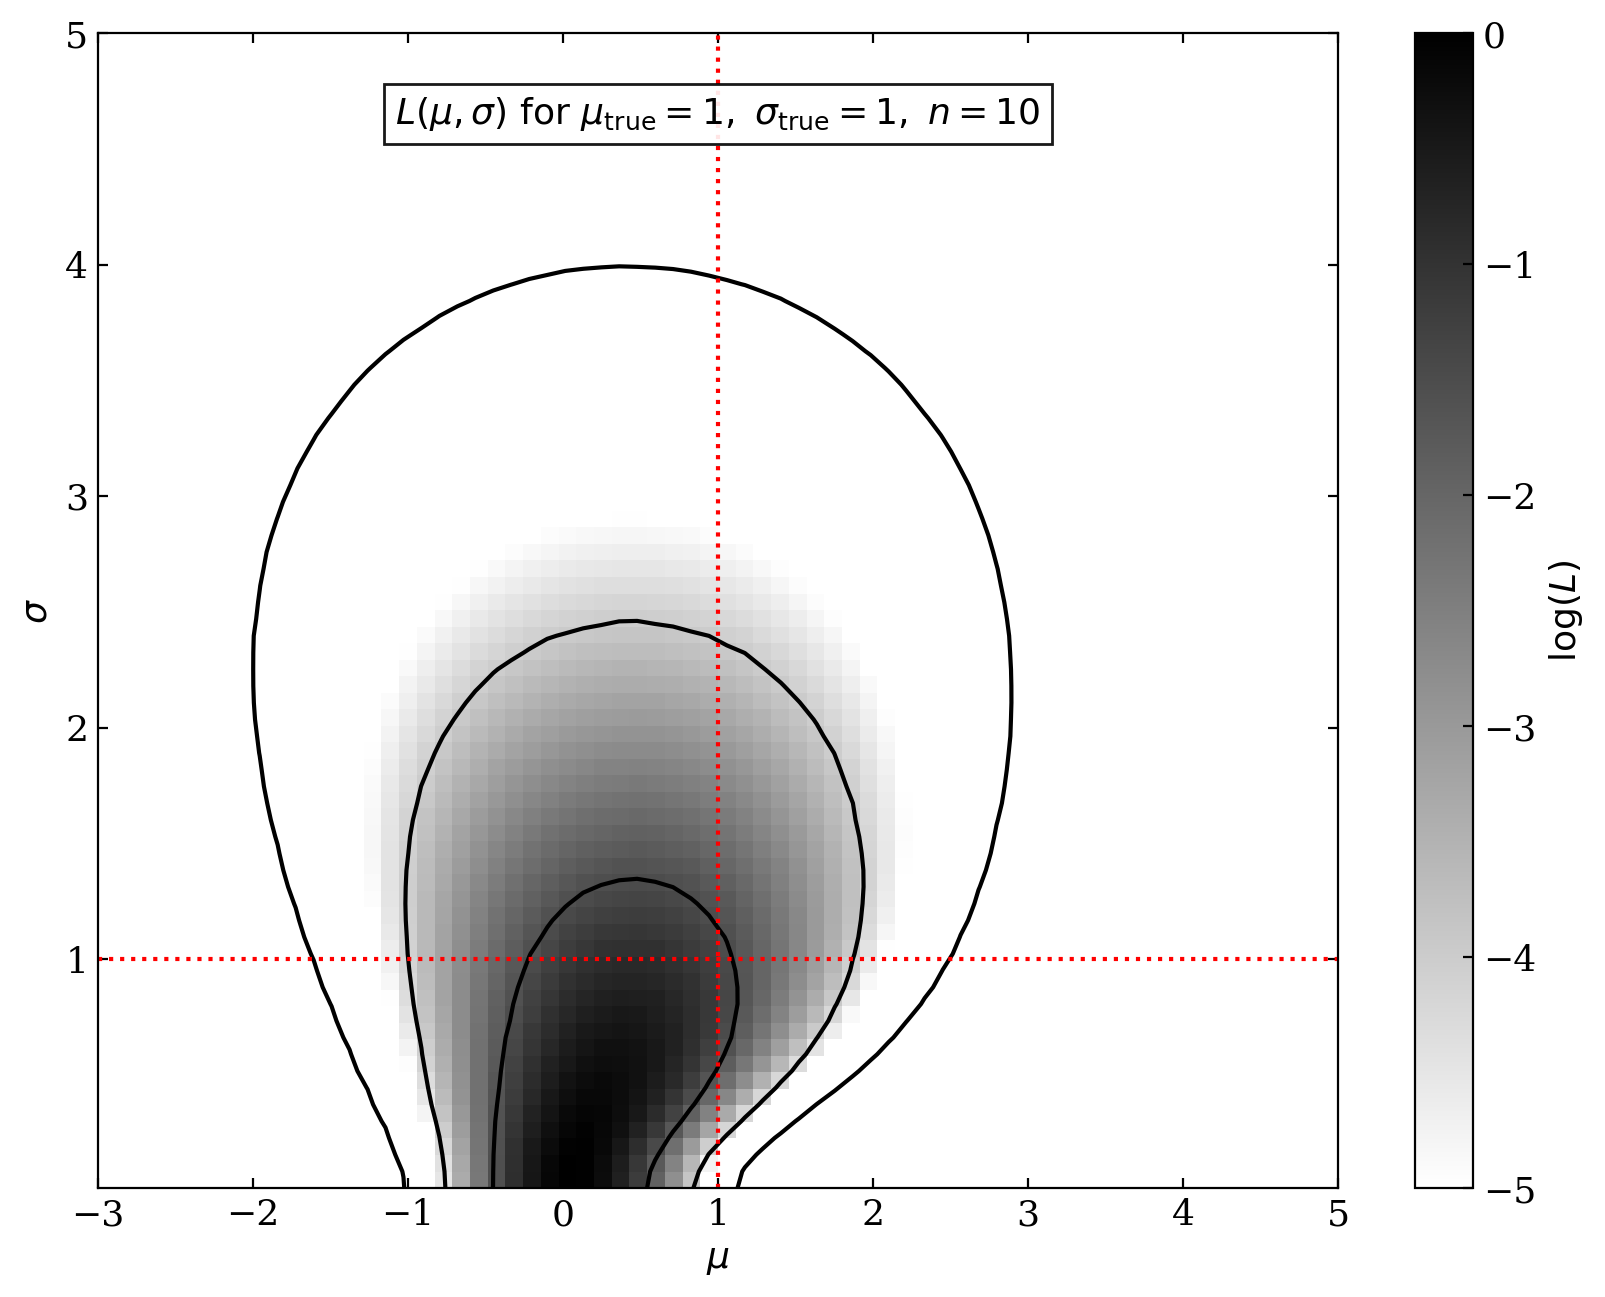

In [24]:
# Execute this cell
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
#np.random.seed(42)

"""
Gaussian Distribution with Gaussian Errors
------------------------------------------
Figure 5.7

The logarithm of the posterior probability density function for :math:`\mu`
and :math:`\sigma`, :math:`L_p(\mu,\sigma)`, for a Gaussian distribution with
heteroscedastic Gaussian measurement errors (sampled uniformly from the 0-3
interval), given by eq. 5.64. The input values are :math:`\mu = 1` and
:math:`\sigma = 1`, and a randomly generated sample has 10 points. Note that
the posterior pdf is not symmetric with respect to the :math:`\mu = 1` line,
and that the outermost contour, which encloses the region that contains 0.997
of the cumulative (integrated) posterior probability, allows solutions with
:math:`\sigma = 0`.
"""
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from astroML.plotting.mcmc import convert_to_stdev

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=13, usetex=False)

#np.random.seed(42)
np.random.seed(4211)

def gaussgauss_logL(xi, ei, mu, sigma):
    """Equation 5.63: gaussian likelihood with gaussian errors"""
    ndim = len(np.broadcast(sigma, mu).shape)

    xi = xi.reshape(xi.shape + tuple(ndim * [1]))
    ei = ei.reshape(ei.shape + tuple(ndim * [1]))

    s2_e2 = sigma ** 2 + ei ** 2
    return -0.5 * np.sum(np.log(s2_e2) + (xi - mu) ** 2 / s2_e2, 0)

#------------------------------------------------------------
# Define the grid and compute logL
#np.random.seed(5)
mu_true = 1.
sigma_true = 1.
N = 10
ei = 3 * np.random.random(N)
xi = np.random.normal(mu_true, np.sqrt(sigma_true ** 2 + ei ** 2))

sigma = np.linspace(0.01, 5, 70)
mu = np.linspace(-3, 5, 70)

logL = gaussgauss_logL(xi, ei, mu, sigma[:, np.newaxis])
logL -= logL.max()

#------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(10, 7.5))
plt.imshow(logL, origin='lower',
           extent=(mu[0], mu[-1], sigma[0], sigma[-1]),
           cmap=plt.cm.binary,
           aspect='auto')
plt.colorbar().set_label(r'$\log(L)$')
plt.clim(-5, 0)

plt.text(0.5, 0.93,
         (r'$L(\mu,\sigma)\ \mathrm{for}\ \mu_{\rm true}=1,\ '
          r'\sigma_{\rm true}=1,\ n=10$'),
         bbox=dict(ec='k', fc='w', alpha=0.9),
         ha='center', va='center', transform=plt.gca().transAxes)

plt.contour(mu, sigma, convert_to_stdev(logL),
            levels=(0.683, 0.955, 0.997),
            colors='k')

plt.axhline(mu_true,c='red',ls='dotted')
plt.axvline(sigma_true,c='red',ls='dotted')

plt.xlabel(r'$\mu$')
plt.ylabel(r'$\sigma$')

plt.show()

When we plot the posterior:

The peak (MAP) is the highest point on the 2D contour (or curve), this is the single most likely parameter value. (and is in the middle of the deepest contour).

We can see that from our toy data set, plotting it didn't get the true values (dotted in red). Once we increase the value of N, this estimate becomes better(try it out). We can also see that the estimate isn't that bad.

## What if the observations came from different populations?

Why would we do this? Well, we can describe the background signals as a uniform distribution and then have a gaussian distribution for each signal.

In this case we are looking at Gaussian **OR** Uniform, and so we add the probability densities together.

> Here we will assume that the location parameter, $\mu$ is known and uncertainties in $x_i$ are negligible compared to $\sigma$

$$p(x_i|A,\mu,\sigma, W) = \frac{A}{\sigma\sqrt{2\pi}} \exp\left(\frac{-(x_i-\mu)^2}{2\sigma^2}\right) + \frac{1-A}{W}.$$

Where we can also see it as:

$$
p(x_i)
=
A\,p_G(x_i)
+
(1-A)\,p_B(x_i)
$$

There are a few things to note here:
1. The background probability is taken between 0 and W, and is 0 otherwise
2. The feature of interest lies between 0 and W
3. $A$ and $A-1$ are the relative strengths of the two components which are anticorrelated

Let's say we have a uniform prior in both A and $\sigma$

$$p(A,\sigma) = C, \; {\rm for} \; 0\le A<A_{\rm max} \; {\rm and} \; 0 \le \sigma \le \sigma_{\rm max},$$

Then the posterior pdf is given as:

$$\ln [p(A,\sigma|\{x_i\},\mu,W)] \propto \sum_{i=1}^N \ln \left[\frac{A}{\sigma \sqrt{2\pi}} \exp\left( \frac{-(x_i-\mu)^2}{2\sigma^2} \right)  + \frac{1-A}{W} \right].$$

Let's say we plot this, we would explore a 2D posterior, each point on the graph would ask if the peak contains this fraction of A of the data, and has this width $\sigma$ , how well would that combination explain everything I observed?

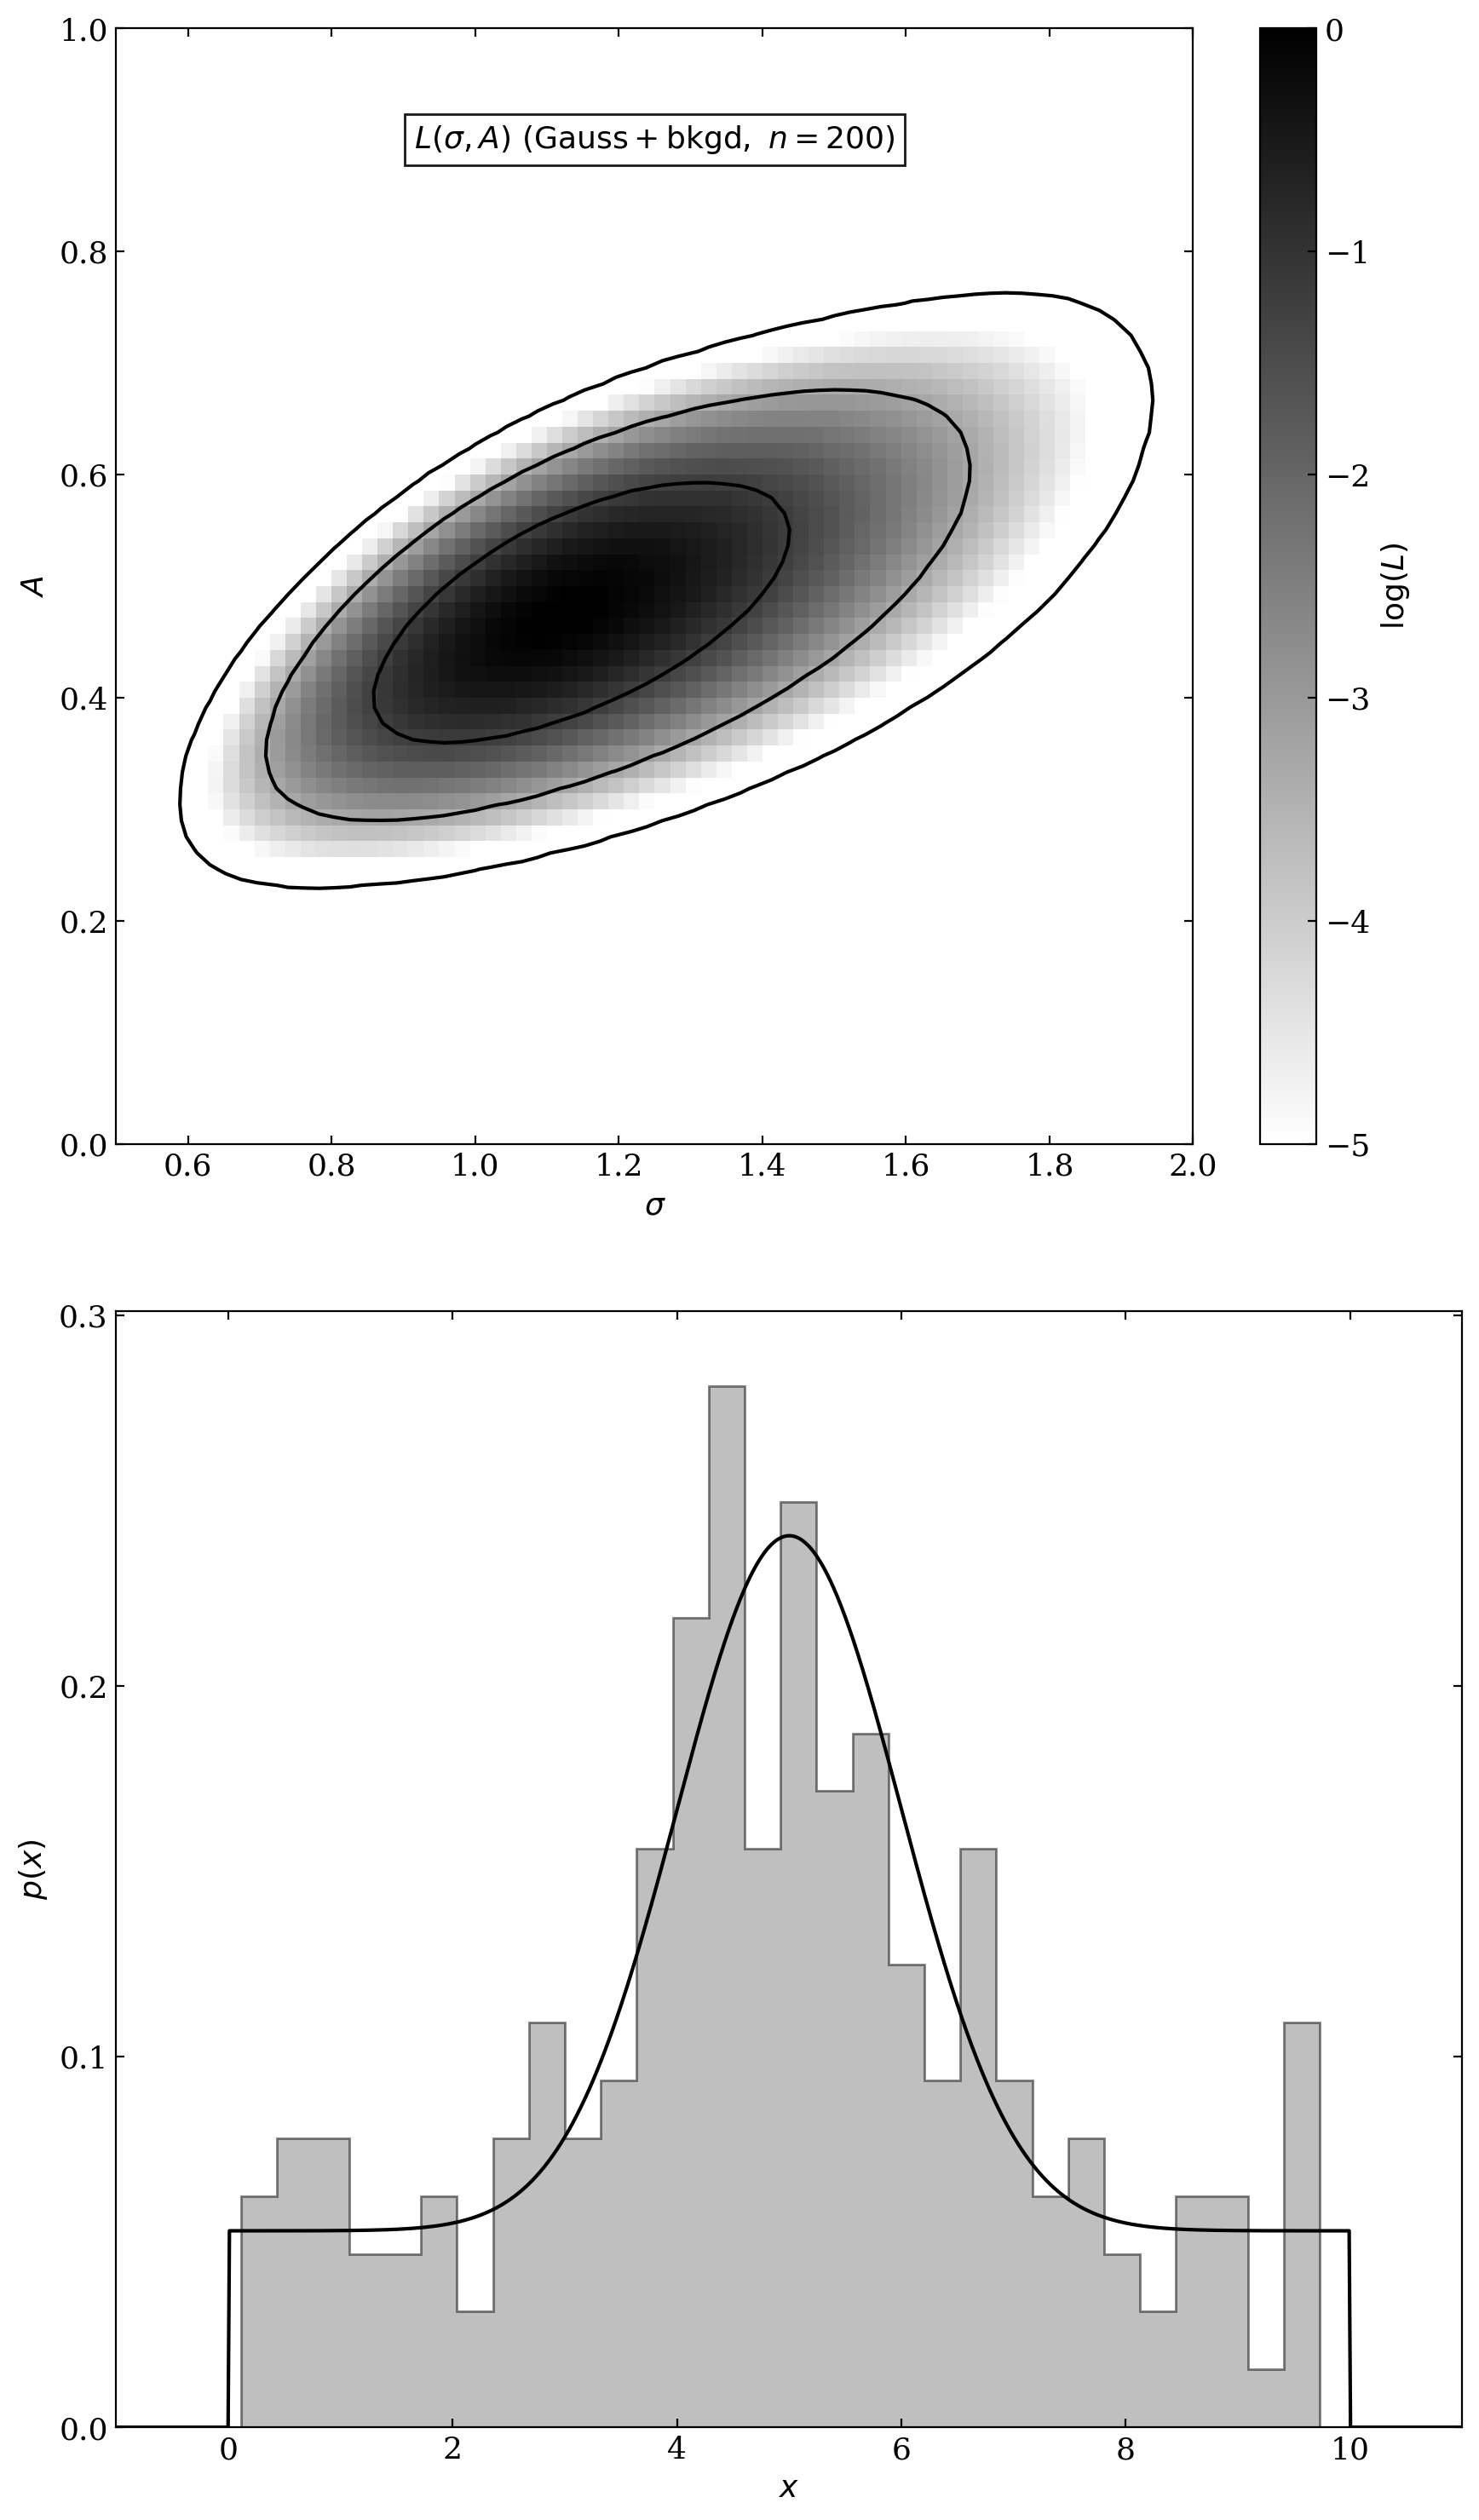

In [25]:
# %load ./code/fig_likelihood_gausslin.py
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from scipy.stats import truncnorm, uniform
from astroML.plotting.mcmc import convert_to_stdev

def gausslin_logL(xi, A=0.5, sigma=1.0, mu=5.0, L=10.0):
    """Equation 5.80: gaussian likelihood with uniform background"""
    xi = np.asarray(xi)

    shape = np.broadcast(sigma, A, mu, L).shape # creates a 2D grid 

    xi = xi.reshape(xi.shape + tuple([1 for s in shape]))

    return np.sum(np.log(A * np.exp(-0.5 * ((xi - mu) / sigma) ** 2)
                         / (sigma * np.sqrt(2 * np.pi))
                         + (1. - A) / L), 0)

#------------------------------------------------------------
# Define the distribution
np.random.seed(0)
mu = 5.0
sigma = 1.0
L = 10.0
A = 0.5
N = 200

xi = np.random.random(N)
NA = np.sum(xi < A)

dist1 = truncnorm((0 - mu) / sigma, (L - mu) / sigma, mu, sigma)
dist2 = uniform(0, 10)

xi[:NA] = dist1.rvs(NA)
xi[NA:] = dist2.rvs(N - NA)

x = np.linspace(-1, 11, 1000)
fracA = NA * 1. / N

#------------------------------------------------------------
# define the (sigma, A) grid and compute logL
sigma = np.linspace(0.5, 2, 70)
A = np.linspace(0, 1, 70)

logL = gausslin_logL(xi, A[:, np.newaxis], sigma)
logL -= logL.max()

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(10, 16))
fig.subplots_adjust(bottom=0.07, left=0.11, hspace=0.15, top=0.95)

ax = fig.add_subplot(211)
plt.imshow(logL, origin='lower', aspect='auto',
           extent=(sigma[0], sigma[-1], A[0], A[-1]),
           cmap=plt.cm.binary)
plt.colorbar().set_label(r'$\log(L)$')
plt.clim(-5, 0)
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$A$')

ax.text(0.5, 0.9, r'$L(\sigma,A)\ (\mathrm{Gauss + bkgd},\ n=200)$',
        bbox=dict(ec='k', fc='w', alpha=0.9),
        ha='center', va='center', transform=plt.gca().transAxes)

ax.contour(sigma, A, convert_to_stdev(logL),
           levels=(0.683, 0.955, 0.997),
           colors='k')

ax2 = plt.subplot(212)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax2.plot(x, fracA * dist1.pdf(x) + (1. - fracA) * dist2.pdf(x), '-k')
ax2.hist(xi, 30, density=True, histtype='stepfilled', fc='gray', alpha=0.5)

ax2.set_ylim(0, 0.301)
ax2.set_xlim(-1, 11)

ax2.set_xlabel('$x$')
ax2.set_ylabel('$p(x)$')
plt.show()

A and $\sigma$ are correlated. We can think of this as when we increase the spread, we are accepting more points and hence increasing $A$.

Looking at the histogram, the black line is the underlying gaussian + uniform background mixture used to generate the histogram. We can see that there is a signal centered at $x=5$. So objects around x = 5 are more likely to produce a signal than ones that are further away

## Model Comparison

We don't have p-values, instead we rank the models probabilistically based on how well they explain the data, using the prior knowledge.

Start with Bayes theorem:

$$p(M,\theta \,|\,D,I) = \frac{p(D\,|\,M,\theta,I)\,\times p(M,\theta\,|\,I)}{p(D\,|\,I)},$$

Here we are technically looking for the model and parameters, but we just want to look at models, so lets marginalise over $\theta$, given the data and prior information:

$$p(M\,|\,D,I) \equiv \int p(M,\theta \,|\,D,I) \, d\theta = 
      \int \frac{p(D\,|\,M,\theta,I)\,p(M,\theta\,|\,I)}{p(D\,|\,I)} \, d\theta =
      \frac{p(M\,|\,I)}{p(D\,|\,I)} \int p(D\,|\,M,\theta,I)\,p(\theta\,|\,M,I) \, d\theta$$

Well, we want to compare models, so where is our comparison?

We compute the ratio of the posterior probabilities for the two models as:

$$O_{21} \equiv \frac{p(M_2|D,I)}{p(M_1|D,I)}.$$

We have seen this before in Day 11, but we are following the lecture here and it is good for a recap.

The posterior probability that model M is correct given the data, D,

$$p(M|D,I) = \frac{p(D|M,I)p(M|I)}{p(D|I)},$$

And so we can assign our symbols and get:

$$O_{21} = \frac{p(D\,|\,M_2,I)\,p(M_2\,|\,I)}{p(D\,|\,M_1,I)\,p(M_1\,|\,I)} \equiv B_{21} \, \frac{p(M_2\,|\,I)}{p(M_1\,|\,I)},$$

Where $B_{21}$ is Bayes factor

This compares how well models fit the data, it is the ratio of data likelihoods averaged over all allowed values of the model parameters.

If two models fit the data equally well, the best one is decided based on priors.

#### Evidence

$$E(M) \equiv p(D\,|\,M, I) = \int p(D\,|\,M, \theta, I) \, p(\theta\,|\,M, I) \, d\theta,$$

$E(M)$ is the marginal likelihood for model M, also known as the evidence. It quantifies the probability that the data would be observed if model M was the correct model.

#### How to interpret $O_{21}$

Jeffreys supposedly proposed a scale for interpreting the odds ratio where $O_{21} > 10$ represents strong evidence in favour of model 2, and $O_{21} > 100$ is decisive evidence. The table below shows this:

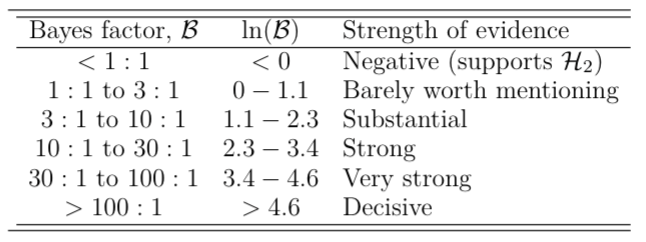

### Hypothesis testing

Here, we compare Models instead of asking whether the data rejects a null hypothesis.

We essentially compare a model to its complement, such that $p(M_1) + p(M_2) = 1$



Results for first 10 points:
  L(M = Cauchy) = 1.18e-12 +/- 5.39e-16
  L(M = Gauss)  = 8.09e-13 +/- 7.45e-16
Bayesian odds ratio of Cauchy-versus-Gaussian Models = 1.45 +/- 0.00134


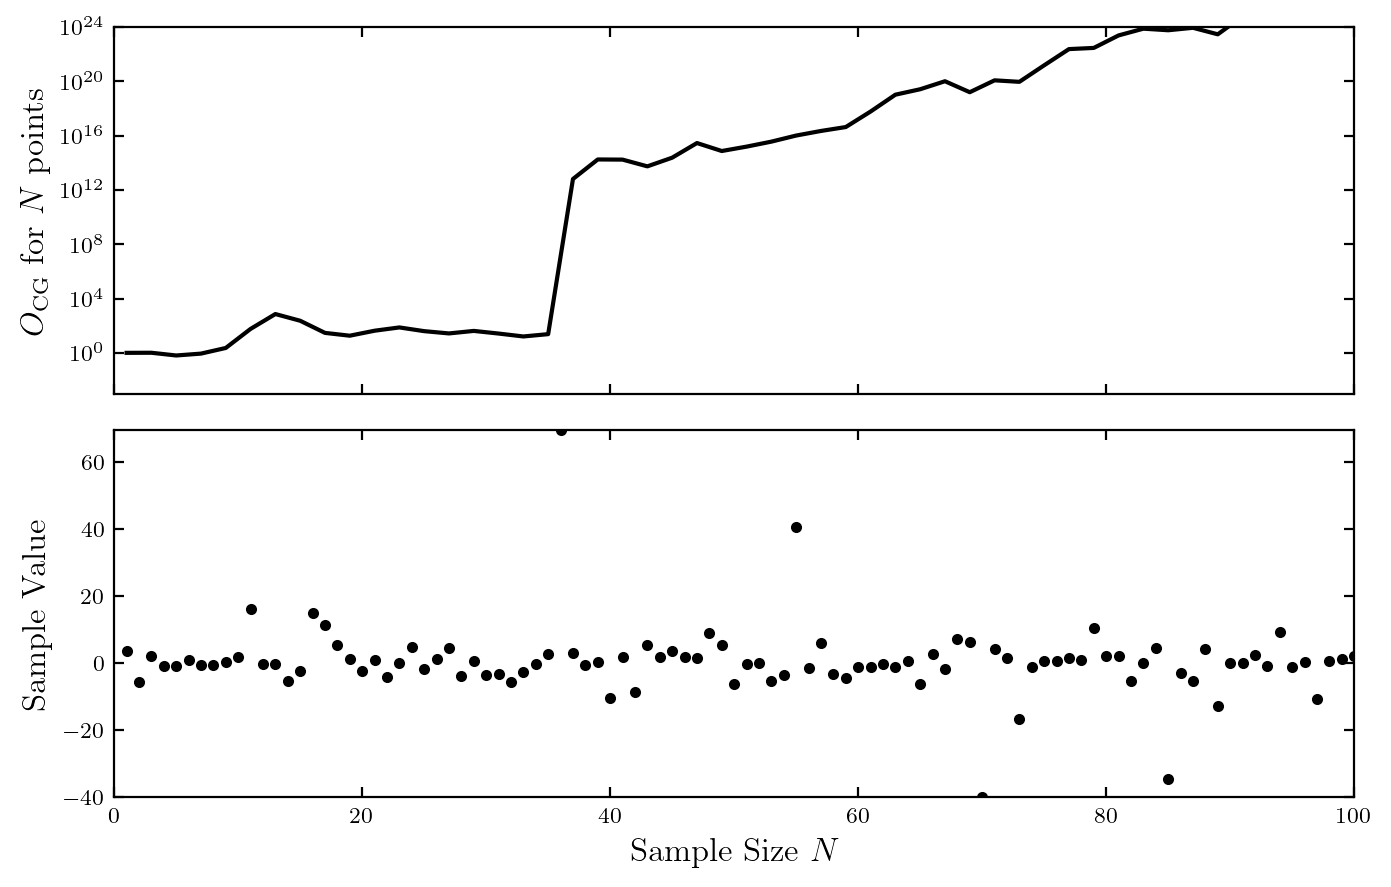

In [26]:
# EXAMPLE from a Cauchy distribution, performing bayesian model comparsion for cauchy and gaussian.

# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from scipy.stats import cauchy, norm
from scipy import integrate

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=True)


def logL_cauchy(xi, gamma, mu,
                mu_min=-10, mu_max=10, sigma_min=0.01, sigma_max=100):
    """Equation 5.74: cauchy likelihood"""
    xi = np.asarray(xi)
    n = xi.size
    shape = np.broadcast(gamma, mu).shape

    xi = xi.reshape(xi.shape + tuple([1 for s in shape]))

    prior_normalization = - (np.log(mu_max - mu_min)
                             + np.log(np.log(sigma_max / sigma_min)))

    return (prior_normalization
            - n * np.log(np.pi)
            + (n - 1) * np.log(gamma)
            - np.sum(np.log(gamma ** 2 + (xi - mu) ** 2), 0))


def logL_gaussian(xi, sigma, mu,
                  mu_min=-10, mu_max=10, sigma_min=0.01, sigma_max=100):
    """Equation 5.57: gaussian likelihood"""
    xi = np.asarray(xi)
    n = xi.size
    shape = np.broadcast(sigma, mu).shape

    xi = xi.reshape(xi.shape + tuple([1 for s in shape]))

    prior_normalization = - (np.log(mu_max - mu_min)
                             + np.log(np.log(sigma_max / sigma_min)))

    return (prior_normalization
            - 0.5 * n * np.log(2 * np.pi)
            - (n + 1) * np.log(sigma)
            - np.sum(0.5 * ((xi - mu) / sigma) ** 2, 0))


def calculate_odds_ratio(xi, epsrel=1E-8, epsabs=1E-15):
    """
    Compute the odds ratio by perfoming a double integral
    over the likelihood space.
    """
    gauss_Ifunc = lambda mu, sigma: np.exp(logL_gaussian(xi, mu, sigma))
    cauchy_Ifunc = lambda mu, gamma: np.exp(logL_cauchy(xi, mu, gamma))

    I_gauss, err_gauss = integrate.dblquad(gauss_Ifunc, -np.inf, np.inf,
                                           lambda x: 0, lambda x: np.inf,
                                           epsabs=epsabs, epsrel=epsrel)
    I_cauchy, err_cauchy = integrate.dblquad(cauchy_Ifunc, -np.inf, np.inf,
                                             lambda x: 0, lambda x: np.inf,
                                             epsabs=epsabs, epsrel=epsrel)

    if I_gauss == 0:
        O_CG = np.inf
        err_O_CG = np.inf
    else:
        O_CG = I_cauchy / I_gauss
        err_O_CG = O_CG * np.sqrt((err_gauss / I_gauss) ** 2)

    return (I_gauss, err_gauss), (I_cauchy, err_cauchy), (O_CG, err_O_CG)


#------------------------------------------------------------
# Draw points from a Cauchy distribution
np.random.seed(44)
mu = 0
gamma = 2
xi = cauchy(mu, gamma).rvs(100)

#------------------------------------------------------------
# compute the odds ratio for the first 10 points
((I_gauss, err_gauss),
 (I_cauchy, err_cauchy),
 (O_CG, err_O_CG)) = calculate_odds_ratio(xi[:10])

print("Results for first 10 points:")
print("  L(M = Cauchy) = %.2e +/- %.2e" % (I_cauchy, err_cauchy))
print("  L(M = Gauss)  = %.2e +/- %.2e" % (I_gauss, err_gauss))
print("Bayesian odds ratio of Cauchy-versus-Gaussian Models = %.3g +/- %.3g" % (O_CG, err_O_CG))

#------------------------------------------------------------
# calculate the results as a function of number of points
Nrange = np.arange(1, 101, 2)
Odds = np.zeros(Nrange.shape)
for i, N in enumerate(Nrange):
    res = calculate_odds_ratio(xi[:N])
    Odds[i] = res[2][0]

#------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(8, 5))
fig.subplots_adjust(hspace=0.1)

ax1 = fig.add_subplot(211, yscale='log')
ax1.plot(Nrange, Odds, '-k')
ax1.set_ylabel(r'$O_\mathrm{CG}$ for $N$ points', fontsize=12)
ax1.set_xlim(0, 100)
ax1.xaxis.set_major_formatter(plt.NullFormatter())
ax1.yaxis.set_major_locator(plt.LogLocator(base=10000.0))
ax1.set_ylim(1e-3, 1e24)

ax2 = fig.add_subplot(212)
ax2.scatter(np.arange(1, len(xi) + 1), xi, lw=0, s=16, c='k')
ax2.set_xlim(0, 100)
ax2.set_xlabel('Sample Size $N$', fontsize=12)
ax2.set_ylabel('Sample Value', fontsize=12)

plt.show() 

We get inconclusive odds ratio for the first 10 points, as the number of data points increases, the ability to discriminate between models increases too. If we increase this value, we start favouring the cauchy distribution

### Coin flip example

Lets assume N draws and k successes.

Our models can be

- $M1$: We know who is flipping the coin, and have seen it flipped before, so this coin has a known heads probability $b_*$ (e.g = 0.5 fair)
- $M2$: I don't know who is flipping the coin or havent seen it before, so the heads probability is unknown, and we give uniform priors from 0-1

For this, we need the binomial distribution:

$$p(k\,|\,b, N) = \frac{N!}{k! \, (N-k)!} \, b^k \, (1-b)^{N-k}$$

For M2:

$$p(k\,|\,b, N, M2) p(b | M2) = \frac{N!}{k! \, (N-k)!} \, b^k \, (1-b)^{N-k}$$

For M1:

$$p(k\,|b, N, b_\ast,M1)\,p(b|b_\ast,M1) = \frac{N!}{k! \, (N-k)!} \, b_\ast^k \, (1-b_\ast)^{N-k}.$$

Hence, we can form the odds ratio:

$$O_{21} = \int_0^1 \left(\frac{b}{b_\ast}\right)^k \left(\frac{1-b}{1-b_\ast}\right)^{N-k} db,$$



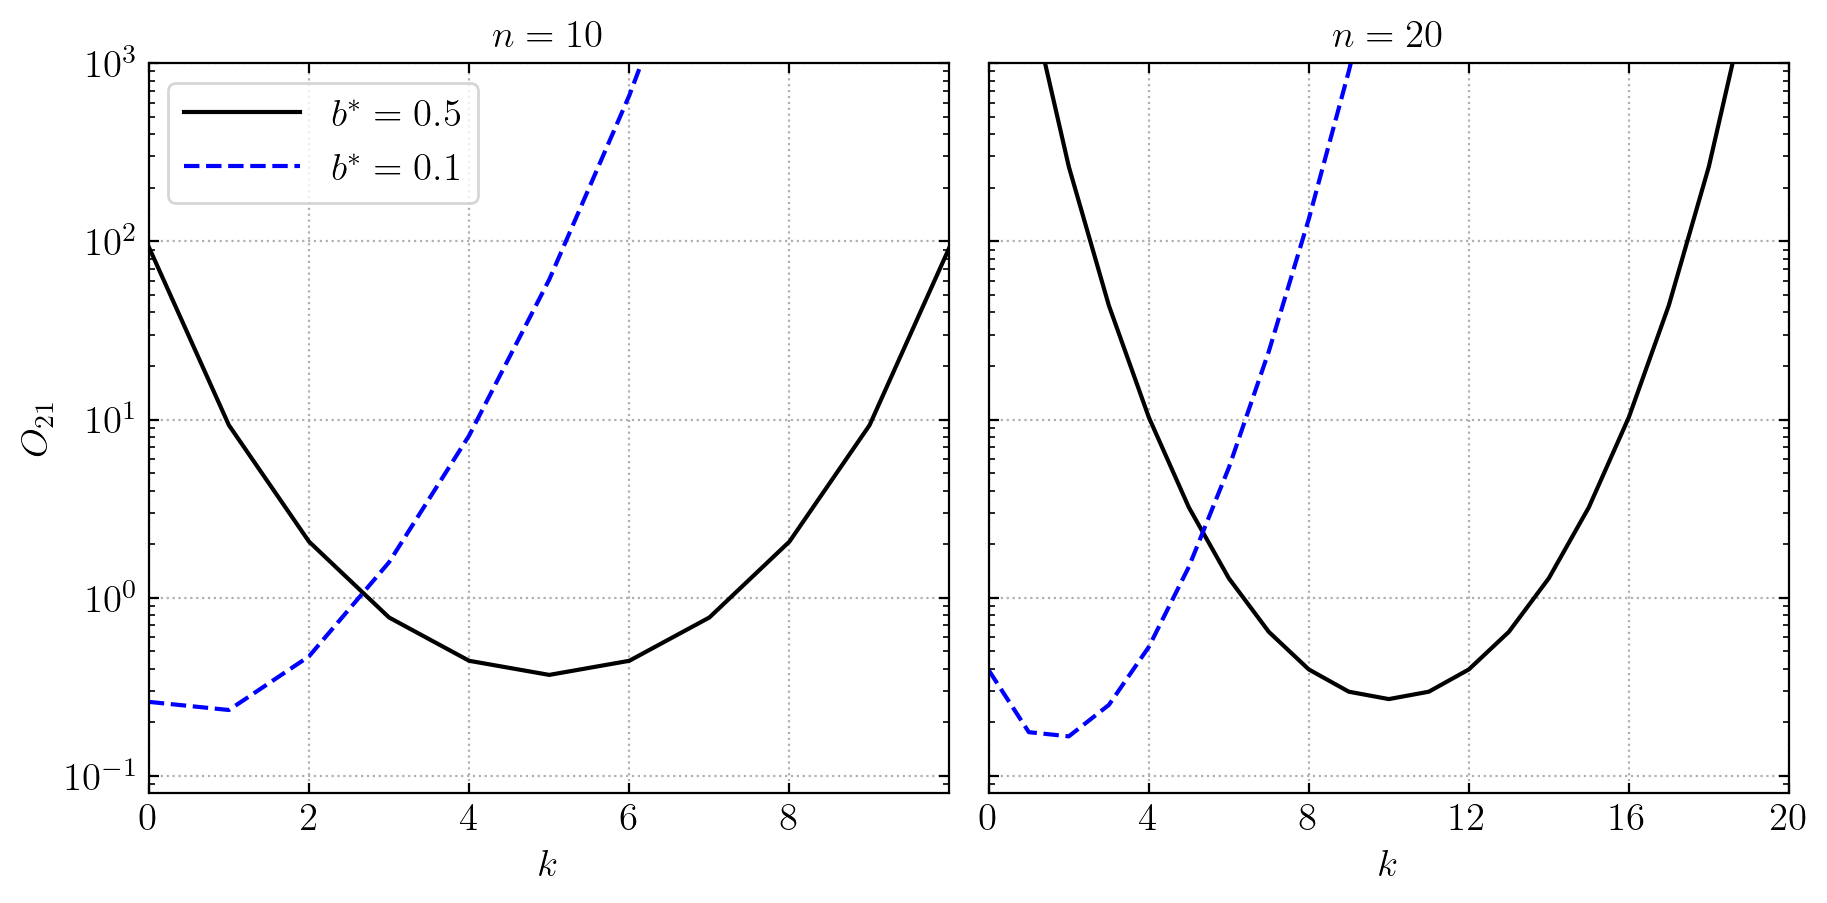

In [27]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from scipy import integrate
from matplotlib import pyplot as plt

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=14, usetex=True)


@np.vectorize
def odds_ratio(n, k, bstar):
    """Odds ratio between M_2, where the heads probability is unknown,
    and M_1, where the heads probability is known to be `bstar`, evaluated
    in the case of `k` heads observed in `n` tosses.

    Eqn. 5.25 in the text
    """
    factor = 1. / (bstar ** k * (1 - bstar) ** (n - k))
    f = lambda b: b ** k * (1 - b) ** (n - k)

    return factor * integrate.quad(f, 0, 1)[0]

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(10, 5))
fig.subplots_adjust(left=0.13, right=0.95, wspace=0.05, bottom=0.15)

subplots = [121, 122]
n_array = [10, 20]

linestyles = ['-k', '--b']
bstar_array = [0.5, 0.1]

for subplot, n in zip(subplots, n_array):
    ax = fig.add_subplot(subplot, yscale='log')
    k = np.arange(n + 1)

    # plot curves for two values of bstar
    for ls, bstar in zip(linestyles, bstar_array):
        ax.plot(k, odds_ratio(n, k, bstar), ls,
                label=r'$b^* = %.1f$' % bstar)

    if subplot == 121:
        ax.set_xlim(0, n - 0.01)
        ax.set_ylabel(r'$O_{21}$')
        ax.legend(loc=2)
    else:
        ax.set_xlim(0, n)
        ax.yaxis.set_major_formatter(plt.NullFormatter())

    ax.set_xlabel('$k$')
    ax.set_title('$n = %i$' % n)
    ax.set_ylim(8E-2, 1E3)
    ax.xaxis.set_major_locator(plt.MultipleLocator(n / 5))
    ax.grid()


plt.show()


We can see two different values of N being compared here, for the behaviour of $O_{21}$ as a function of $k$.

The solid black line represents a fair coin, whereas the dashed blue line representing a coin heavily biased towards tails $b_* =0.1$

As sample size increases, the ability to distinguish between two hypothesis increases